<a href="https://colab.research.google.com/github/suprajamudipalli/codealpha_tasks/blob/main/task2_handwritten_character_recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

import libraries

In [1]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np

load dataset

In [2]:
(x_train, y_train), (x_test, y_test) = datasets.mnist.load_data()

print("Training Images:", x_train.shape)
print("Testing Images:", x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training Images: (60000, 28, 28)
Testing Images: (10000, 28, 28)


display sample image

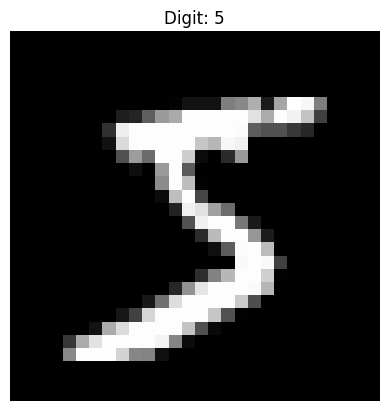

In [3]:
plt.imshow(x_train[0], cmap='gray')
plt.title(f"Digit: {y_train[0]}")
plt.axis('off')
plt.show()

preprocess data

In [4]:
x_train = x_train / 255.0
x_test = x_test / 255.0

x_train = x_train.reshape((-1, 28, 28, 1))
x_test = x_test.reshape((-1, 28, 28, 1))

build cnn mode

In [5]:
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu',
                  input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(64, activation='relu'),

    layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


compile model

In [6]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

train model

In [7]:
history = model.fit(
    x_train,
    y_train,
    epochs=5,
    validation_data=(x_test, y_test)
)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 51s 27ms/step - accuracy: 0.9533 - loss: 0.1526 - val_accuracy: 0.9807 - val_loss: 0.0593
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 51s 27ms/step - accuracy: 0.9846 - loss: 0.0497 - val_accuracy: 0.9879 - val_loss: 0.0385
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 48s 26ms/step - accuracy: 0.9890 - loss: 0.0352 - val_accuracy: 0.9886 - val_loss: 0.0329
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 47s 25ms/step - accuracy: 0.9916 - loss: 0.0258 - val_accuracy: 0.9894 - val_loss: 0.0324
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 48s 25ms/step - accuracy: 0.9934 - loss: 0.0203 - val_accuracy: 0.9910 - val_loss: 0.0283


evaluate model

In [8]:
loss, accuracy = model.evaluate(x_test, y_test)

print("Accuracy:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9910 - loss: 0.0283
Accuracy: 0.9909999966621399


predict a digit

In [9]:
prediction = model.predict(x_test)

predicted_digit = np.argmax(prediction[0])

print("Predicted:", predicted_digit)
print("Actual:", y_test[0])

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
Predicted: 7
Actual: 7


show prediction

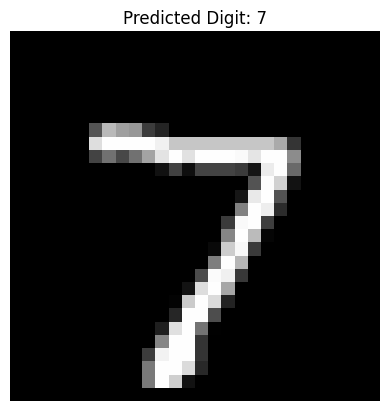

In [10]:
plt.imshow(x_test[0].reshape(28,28), cmap='gray')
plt.title(f"Predicted Digit: {predicted_digit}")
plt.axis('off')
plt.show()